# NutriVision — vision training notebook

We work through **TrainingStrategy.txt** one phase at a time. This notebook owns the
**data pipeline**: it inventories every dataset under `Data/`, harmonizes the class
names into one vocabulary, and merges everything into a single YOLO tree with one
`data.merged.yaml`. Each section is its own cell group so we can run, inspect, move on.

| Section | Phase | What we do there |
|---------|-------|------------------|
| Setup | — | Paths, imports for data work |
| Phase A | Inventory | What is under `Data/`, yaml, counts, samples |
| Phase B | Harmonize classes | One vocabulary, rename/map rules |
| Phase C | Merge / layout | Merge **all** datasets → one tree + merged `data.yaml` |

The actual fine-tune runs from the standalone **`train.py`** (not in this notebook), on
the merged `data.merged.yaml`. Progress is logged in **TrainingDocument.txt**.

### Imports

We import `Path` for filesystem work and `yaml` for reading each dataset’s `data.yaml`.

In [2]:
from pathlib import Path

import yaml

### Folder paths

We store the notebook directory and the `Data/` folder in variables. Every following cell uses `DATA_DIR` so we always point at the same place on disk.

In [3]:
NOTEBOOK_DIR = Path.cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "Data"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.is_dir())

MERGED_DIR = DATA_DIR / "merged"
MERGED_TRAIN_YAML = MERGED_DIR / "data.merged.yaml"

print("MERGED_DIR:", MERGED_DIR)
print("MERGED_TRAIN_YAML exists:", MERGED_TRAIN_YAML.is_file())


NOTEBOOK_DIR: F:\Final Project\Nutrivision\Code\Training model
DATA_DIR: F:\Final Project\Nutrivision\Code\Training model\Data
DATA_DIR exists: True
MERGED_DIR: F:\Final Project\Nutrivision\Code\Training model\Data\merged
MERGED_TRAIN_YAML exists: True


## Phase A — Inventory

We walk through what is under `Data/` before any training: folder names, layout, then each `data.yaml` and what it defines.

### List top-level folder names

Print the **names** of everything sitting directly inside `Data/`. Each name is one dataset folder we may use.

In [4]:
for p in sorted(DATA_DIR.iterdir()):
    print(p.name)


aicook
FOOD-INGREDIENTS dataset.v4i.yolov12
Fridge detection
Fridge Object.v3i.yolov12
Fridge objects.v12i.yolov12
LVIS_Fruits_And_Vegetables
merged


### One level inside each folder

For each top-level folder, print **one level** of children only. This shows whether we see `data.yaml`, `train`/`valid`/`test`, or a layout like `images/` and `labels/`.

In [5]:
for p in sorted(DATA_DIR.iterdir()):
    if not p.is_dir():
        print(p.name)
        continue
    print(p.name + ":")
    for f in sorted(p.iterdir()):
        print("  " + f.name)
    print()


aicook:
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test
  train
  valid

FOOD-INGREDIENTS dataset.v4i.yolov12:
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test
  train
  valid

Fridge detection:
  README.roboflow.txt
  train

Fridge Object.v3i.yolov12:
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test
  train
  valid

Fridge objects.v12i.yolov12:
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test
  train
  valid

LVIS_Fruits_And_Vegetables:
  data.yaml
  images
  labels

merged:
  data.merged.yaml
  test
  train
  val



### Image file extensions

When we count images later, we only count files with these extensions. Defining the set here keeps every count consistent.

In [6]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


### Helpers

**find_data_yaml_files** — search under a folder and return every `data.yaml` path.

**names_to_list** — turn `names` from yaml into a plain list (list or dict style exports).

**count_images_under** — count image files under a path using `IMG_EXTS`.

**count_label_txts_under** — count `.txt` label files under a path.


In [7]:
def find_data_yaml_files(root: Path) -> list[Path]:
    return sorted(root.rglob("data.yaml"))


def names_to_list(names) -> list:
    if names is None:
        return []
    if isinstance(names, dict):
        keys = sorted(names.keys(), key=lambda k: int(k) if str(k).isdigit() else str(k))
        return [names[k] for k in keys]
    return list(names)


def count_images_under(folder: Path) -> int:
    if not folder.is_dir():
        return 0
    return sum(
        1
        for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )


def count_label_txts_under(folder: Path) -> int:
    if not folder.is_dir():
        return 0
    return sum(1 for p in folder.rglob("*.txt") if p.is_file())


### List every `data.yaml` path

How many yaml files we have and where they live under `Data/`.


In [8]:
yaml_files = find_data_yaml_files(DATA_DIR)

print("data.yaml count:", len(yaml_files))
print()
for yp in yaml_files:
    print(yp.relative_to(DATA_DIR))


data.yaml count: 5

aicook\data.yaml
FOOD-INGREDIENTS dataset.v4i.yolov12\data.yaml
Fridge Object.v3i.yolov12\data.yaml
Fridge objects.v12i.yolov12\data.yaml
LVIS_Fruits_And_Vegetables\data.yaml


### Read `nc` and class names from each `data.yaml`

For every path in `yaml_files`, load the file and print the class count (`nc`) and every class name with its id. This is what the model would be trained to predict for that dataset.

In [9]:
for yp in yaml_files:
    data = yaml.safe_load(yp.read_text(encoding="utf-8"))
    names = names_to_list(data.get("names"))
    nc = data.get("nc", len(names))
    print("---", yp.relative_to(DATA_DIR), "---")
    print("nc:", nc)
    for i, name in enumerate(names):
        print(f"  {i}: {name}")
    print()


--- aicook\data.yaml ---
nc: 30
  0: apple
  1: banana
  2: beef
  3: blueberries
  4: bread
  5: butter
  6: carrot
  7: cheese
  8: chicken
  9: chicken_breast
  10: chocolate
  11: corn
  12: eggs
  13: flour
  14: goat_cheese
  15: green_beans
  16: ground_beef
  17: ham
  18: heavy_cream
  19: lime
  20: milk
  21: mushrooms
  22: onion
  23: potato
  24: shrimp
  25: spinach
  26: strawberries
  27: sugar
  28: sweet_potato
  29: tomato

--- FOOD-INGREDIENTS dataset.v4i.yolov12\data.yaml ---
nc: 120
  0: Akabare Khursani
  1: Apple
  2: Artichoke
  3: Ash Gourd -Kubhindo-
  4: Asparagus -Kurilo-
  5: Avocado
  6: Bacon
  7: Bamboo Shoots -Tama-
  8: Banana
  9: Beans
  10: Beaten Rice -Chiura-
  11: Beef
  12: Beetroot
  13: Bethu ko Saag
  14: Bitter Gourd
  15: Black Lentils
  16: Black beans
  17: Bottle Gourd -Lauka-
  18: Bread
  19: Brinjal
  20: Broad Beans -Bakullo-
  21: Broccoli
  22: Buff Meat
  23: Butter
  24: Cabbage
  25: Capsicum
  26: Carrot
  27: Cassava -Ghar T

### Folders without a `data.yaml`

Top-level folders that are not the parent of any `data.yaml` we found (right now that is just Fridge detection).


In [10]:
yaml_parents = {yp.parent.resolve() for yp in yaml_files}

for p in sorted(DATA_DIR.iterdir()):
    if not p.is_dir():
        continue
    if p.resolve() in yaml_parents:
        continue
    print(p.name)


Fridge detection
merged


### `aicook` — images and labels per split (on disk)

`aicook` uses folders `train/`, `valid/`, and `test/` with `images/` and `labels/` inside each. We count files there (not the `../train/images` paths written in `data.yaml`, which point outside this folder).

In [11]:
aicook_dir = DATA_DIR / "aicook"

for split in ("train", "valid", "test"):
    images_dir = aicook_dir / split / "images"
    labels_dir = aicook_dir / split / "labels"
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train
  images: 362
  labels: 362

valid
  images: 103
  labels: 103

test
  images: 51
  labels: 51



### `FOOD-INGREDIENTS dataset.v4i.yolov12` — images and labels per split (on disk)

Same layout as `aicook`: `train/`, `valid/`, and `test/` each with `images/` and `labels/`. Counts are from this folder on disk, not from `data.yaml` paths.

In [12]:
food_dir = DATA_DIR / "FOOD-INGREDIENTS dataset.v4i.yolov12"

for split in ("train", "valid", "test"):
    images_dir = food_dir / split / "images"
    labels_dir = food_dir / split / "labels"
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train
  images: 8331
  labels: 8331

valid
  images: 823
  labels: 823

test
  images: 572
  labels: 572



### `Fridge Object.v3i.yolov12` — images and labels per split (on disk)

Same Roboflow layout: `train/`, `valid/`, and `test/` with `images/` and `labels/` under each split.

In [13]:
fridge_object_dir = DATA_DIR / "Fridge Object.v3i.yolov12"

for split in ("train", "valid", "test"):
    images_dir = fridge_object_dir / split / "images"
    labels_dir = fridge_object_dir / split / "labels"
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train


  images: 5502
  labels: 5502

valid
  images: 3040
  labels: 3040

test
  images: 1331
  labels: 1331



### `Fridge objects.v12i.yolov12` — images and labels per split (on disk)

Same Roboflow layout: `train/`, `valid/`, and `test/` with `images/` and `labels/` under each split. Smaller class list (nc=10 in `data.yaml`) than `Fridge Object.v3i.yolov12`.

In [14]:
fridge_objects_v12_dir = DATA_DIR / "Fridge objects.v12i.yolov12"

for split in ("train", "valid", "test"):
    images_dir = fridge_objects_v12_dir / split / "images"
    labels_dir = fridge_objects_v12_dir / split / "labels"
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train
  images: 2184
  labels: 2184

valid
  images: 123
  labels: 123

test
  images: 106
  labels: 106



### `LVIS_Fruits_And_Vegetables` — images and labels per split (on disk)

Parallel folders `images/<split>` and `labels/<split>`. Splits are `train`, `val`, and `test` (not `valid`). Counts below are on disk; `data.yaml` also maps both `val` and `test` to `images/test` — we do not use that here.

In [15]:
lvis_dir = DATA_DIR / "LVIS_Fruits_And_Vegetables"

for split in ("train", "val", "test"):
    images_dir = lvis_dir / "images" / split
    labels_dir = lvis_dir / "labels" / split
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train
  images: 6721
  labels: 6721

val
  images: 1500
  labels: 1500

test
  images: 180
  labels: 180



### `Fridge detection` — train only, no `data.yaml`

Only a `train/` folder: images sit directly in `train/` (not `train/images/`). Roboflow exported **COCO** labels in `train/_annotations.coco.json`, not per-image `.txt` files. We still run our usual image and `.txt` counts so we can compare to YOLO datasets.

In [16]:
fridge_det_dir = DATA_DIR / "Fridge detection"
train_dir = fridge_det_dir / "train"
coco_path = train_dir / "_annotations.coco.json"

print("train")
print("  images:", count_images_under(train_dir))
print("  labels (.txt):", count_label_txts_under(train_dir))
print("  _annotations.coco.json:", "yes" if coco_path.is_file() else "no")
print()


train
  images: 3148
  labels (.txt): 0
  _annotations.coco.json: yes



### Sample YOLO image + label (`aicook` train)

We take the first image in `train/images/` (sorted by name) and the matching `.txt` in `train/labels/`. Each label line is `class_id x_center y_center width height` with box coords normalized to 0–1. Class names come from this folder’s `data.yaml`.

In [17]:
aicook_dir = DATA_DIR / "aicook"
images_dir = aicook_dir / "train" / "images"
labels_dir = aicook_dir / "train" / "labels"

sample_image = sorted(
    p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS
)[0]
sample_label = labels_dir / f"{sample_image.stem}.txt"

with open(aicook_dir / "data.yaml", encoding="utf-8") as f:
    aicook_yaml = yaml.safe_load(f)
class_names = names_to_list(aicook_yaml.get("names"))

print("image:", sample_image)
print("label:", sample_label)
print("label exists:", sample_label.is_file())
print()
print("label file (raw):")
print(sample_label.read_text(encoding="utf-8").rstrip() or "(empty)")
print()
print("decoded (class_name x_center y_center width height):")
for line in sample_label.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line:
        continue
    parts = line.split()
    if len(parts) != 5:
        print("  ?", line)
        continue
    cid = int(parts[0])
    name = class_names[cid] if 0 <= cid < len(class_names) else f"id_{cid}"
    print(f"  {name}", " ".join(parts[1:]))


image: F:\Final Project\Nutrivision\Code\Training model\Data\aicook\train\images\DSC_5680_JPG_jpg.rf.848821bf3a69ca77968602dbe5aadcb5.jpg
label: F:\Final Project\Nutrivision\Code\Training model\Data\aicook\train\labels\DSC_5680_JPG_jpg.rf.848821bf3a69ca77968602dbe5aadcb5.txt
label exists: True

label file (raw):
2 0.5726825842696629 0.47201492537313433 0.2169943820224719 0.051305970149253734
13 0.5765449438202247 0.5890858208955224 0.16292134831460675 0.11194029850746269
29 0.7278792134831461 0.5916511194029851 0.1425561797752809 0.0732276119402985
25 0.3967696629213483 0.6075093283582089 0.2598314606741573 0.0732276119402985
7 0.702247191011236 0.8875932835820896 0.11797752808988764 0.0708955223880597
24 0.42837078651685395 0.8903917910447762 0.12640449438202248 0.058768656716417914
27 0.3377808988764045 0.17537313432835822 0.12219101123595505 0.13619402985074627
27 0.5898876404494382 0.18120335820895522 0.1151685393258427 0.12080223880597014
6 0.6313202247191011 0.21012126865671643 0

## Phase B — Harmonize classes

We build one product class list from every YOLO `data.yaml` under `Data/`. v1 can be a subset later; first we collect names, then fix casing and synonyms before any merge or training. (`Fridge detection` is COCO-only — we handle it when we convert or merge that folder.)

### Collect class names from each `data.yaml`

We load each `data.yaml` from Phase A into `dataset_classes`: dataset folder name → list of class name strings. Later cells use this dict; we do not reload yaml files each time.

In [18]:
dataset_classes = {}

for yp in yaml_files:
    with open(yp, encoding="utf-8") as f:
        doc = yaml.safe_load(f)
    names = names_to_list(doc.get("names"))
    dataset_classes[yp.parent.name] = names

for ds_name in sorted(dataset_classes):
    print(f"{ds_name}: {len(dataset_classes[ds_name])} classes")


FOOD-INGREDIENTS dataset.v4i.yolov12: 120 classes
Fridge Object.v3i.yolov12: 53 classes
Fridge objects.v12i.yolov12: 10 classes
LVIS_Fruits_And_Vegetables: 63 classes
aicook: 30 classes


### Casing and spelling variants (case-insensitive)

We lower-case each name and group spellings. When one group has more than one distinct string, we have a harmonization candidate (e.g. `tomato` vs `Tomato`).

In [19]:
all_names = []
for names in dataset_classes.values():
    all_names.extend(names)

by_lower = {}
for name in all_names:
    by_lower.setdefault(name.lower().strip(), set()).add(name)

collisions = {key: variants for key, variants in by_lower.items() if len(variants) > 1}

print("name entries across all yaml lists:", len(all_names))
print("unique exact spellings:", len(set(all_names)))
print("unique case-insensitive keys:", len(by_lower))
print("groups with multiple spellings:", len(collisions))
print()

for key in sorted(collisions):
    print(f"  {key!r} -> {sorted(collisions[key])}")


name entries across all yaml lists: 276
unique exact spellings: 226
unique case-insensitive keys: 191
groups with multiple spellings: 35

  'apple' -> ['Apple', 'apple']
  'artichoke' -> ['Artichoke', 'artichoke']
  'avocado' -> ['Avocado', 'avocado']
  'bacon' -> ['Bacon', 'bacon']
  'banana' -> ['Banana', 'banana']
  'beef' -> ['Beef', 'beef']
  'bread' -> ['Bread', 'bread']
  'broccoli' -> ['Broccoli', 'broccoli']
  'butter' -> ['Butter', 'butter']
  'cabbage' -> ['Cabbage', 'cabbage']
  'carrot' -> ['Carrot', 'carrot']
  'cauliflower' -> ['Cauliflower', 'cauliflower']
  'cheese' -> ['Cheese', 'cheese']
  'chicken' -> ['Chicken', 'chicken']
  'corn' -> ['Corn', 'corn']
  'cucumber' -> ['Cucumber', 'cucumber']
  'egg' -> ['Egg', 'egg']
  'fish' -> ['Fish', 'fish']
  'garlic' -> ['Garlic', 'garlic']
  'ginger' -> ['Ginger', 'ginger']
  'ham' -> ['Ham', 'ham']
  'milk' -> ['Milk', 'milk']
  'mushroom' -> ['Mushroom', 'mushroom']
  'onion' -> ['Onion', 'onion']
  'orange' -> ['Orange', 

### Helpers

**alias_parts** — split a class string on `/` (LVIS-style synonyms on one line).

**proposed_canonical** — v1 naming rule: first alias, lowercased, spaces → underscores (e.g. `eggplant/aubergine` → `eggplant`).

In [20]:
def alias_parts(name: str) -> list[str]:
    return [part.strip() for part in name.split("/") if part.strip()]


def proposed_canonical(name: str) -> str:
    first = alias_parts(name)[0]
    return first.lower().replace(" ", "_")


### Slash-separated class names

Any name with more than one `alias_parts` entry (usually from LVIS). These need a single canonical label before merge or training.

In [21]:
slash_names = sorted(
    {name for names in dataset_classes.values() for name in names if len(alias_parts(name)) > 1}
)

print("slash-separated names:", len(slash_names))
print()
for name in slash_names:
    parts = alias_parts(name)
    print(f"  {name!r}")
    print(f"    parts ({len(parts)}): {parts}")


slash-separated names: 19

  'bean curd/tofu'
    parts (2): ['bean curd', 'tofu']
  'bell pepper/capsicum'
    parts (2): ['bell pepper', 'capsicum']
  'cantaloup/cantaloupe'
    parts (2): ['cantaloup', 'cantaloupe']
  'cayenne/cayenne spice/cayenne pepper/cayenne pepper spice/red pepper/red pepper'
    parts (6): ['cayenne', 'cayenne spice', 'cayenne pepper', 'cayenne pepper spice', 'red pepper', 'red pepper']
  'chickpea/garbanzo'
    parts (2): ['chickpea', 'garbanzo']
  'chili/chili vegetable/chili pepper/chili pepper vegetable/chilli/chilli vegetable/chilly/chilly'
    parts (8): ['chili', 'chili vegetable', 'chili pepper', 'chili pepper vegetable', 'chilli', 'chilli vegetable', 'chilly', 'chilly']
  'coconut/cocoanut'
    parts (2): ['coconut', 'cocoanut']
  'cucumber/cuke'
    parts (2): ['cucumber', 'cuke']
  'date/date fruit'
    parts (2): ['date', 'date fruit']
  'edible corn/corn/maize'
    parts (3): ['edible corn', 'corn', 'maize']
  'eggplant/aubergine'
    parts (2): 

### Synonym groups via `proposed_canonical`

Each unique exact spelling maps to one proposed key. When several exact strings share a key, they are harmonization candidates (casing, slashes, or spelling like `chicken_breast` vs `chicken breast`).

In [22]:
unique_exact = sorted(set(all_names))

by_proposed = {}
for name in unique_exact:
    by_proposed.setdefault(proposed_canonical(name), set()).add(name)

merge_groups = {
    key: variants for key, variants in by_proposed.items() if len(variants) > 1
}

print("unique exact spellings:", len(unique_exact))
print("unique proposed_canonical keys:", len(by_proposed))
print("merge groups (multiple exact → one proposed):", len(merge_groups))
print()

for key in sorted(merge_groups):
    print(f"  {key!r} <- {sorted(merge_groups[key])}")


unique exact spellings: 226
unique proposed_canonical keys: 181
merge groups (multiple exact → one proposed): 39

  'apple' <- ['Apple', 'apple']
  'artichoke' <- ['Artichoke', 'artichoke']
  'avocado' <- ['Avocado', 'avocado']
  'bacon' <- ['Bacon', 'bacon']
  'banana' <- ['Banana', 'banana']
  'beef' <- ['Beef', 'beef']
  'bread' <- ['Bread', 'bread']
  'broccoli' <- ['Broccoli', 'broccoli']
  'butter' <- ['Butter', 'butter']
  'cabbage' <- ['Cabbage', 'cabbage']
  'carrot' <- ['Carrot', 'carrot']
  'cauliflower' <- ['Cauliflower', 'cauliflower']
  'cheese' <- ['Cheese', 'cheese']
  'chicken' <- ['Chicken', 'chicken']
  'chicken_breast' <- ['chicken breast', 'chicken_breast']
  'corn' <- ['Corn', 'corn']
  'cucumber' <- ['Cucumber', 'cucumber', 'cucumber/cuke']
  'egg' <- ['Egg', 'egg']
  'eggplant' <- ['eggplant', 'eggplant/aubergine']
  'fish' <- ['Fish', 'fish']
  'garlic' <- ['Garlic', 'garlic', 'garlic/ail']
  'ginger' <- ['Ginger', 'ginger', 'ginger/gingerroot']
  'ham' <- ['Ha

## Phase C — Merge / layout

**Goal:** one merged YOLO tree + `data.yaml` from **all** datasets under `Data/` (aicook, FOOD, both fridge YOLO exports, LVIS, Fridge detection after COCO→YOLO).

**Output:** `Data/merged/` (`train`/`val`/`test` with `images/` + `labels/`) and `data.merged.yaml`, which `train.py` reads for the fine-tune.

### Full merge — class list from all yaml datasets

For the real training set we need one `names` list shared by every source. We build `MERGED_CLASS_NAMES` as the sorted set of `proposed_canonical` over every class string in all five `data.yaml` datasets (181 keys with current data). Fridge detection (COCO) is added in a later cell.

In [30]:
MERGED_CLASS_NAMES = sorted(
    {
        proposed_canonical(name)
        for names in dataset_classes.values()
        for name in names
    }
)

merged_index = {name: i for i, name in enumerate(MERGED_CLASS_NAMES)}

print("merged class count (nc):", len(MERGED_CLASS_NAMES))
print()
for i, name in enumerate(MERGED_CLASS_NAMES):
    print(f"  {i}: {name}")


merged class count (nc): 181

  0: akabare_khursani
  1: almond
  2: apple
  3: apricot
  4: artichoke
  5: ash_gourd_-kubhindo-
  6: asparagus
  7: asparagus_-kurilo-
  8: avocado
  9: bacon
  10: bamboo_shoots_-tama-
  11: banana
  12: bean
  13: bean_curd
  14: beans
  15: beaten_rice_-chiura-
  16: beef
  17: beetroot
  18: bell_pepper
  19: bethu_ko_saag
  20: bitter_gourd
  21: black_beans
  22: black_lentils
  23: blackberry
  24: blueberries
  25: blueberry
  26: bottle_gourd_-lauka-
  27: bread
  28: brinjal
  29: broad_beans_-bakullo-
  30: broccoli
  31: brussels_sprouts
  32: buff_meat
  33: butter
  34: cabbage
  35: cantaloup
  36: capsicum
  37: carrot
  38: cassava_-ghar_tarul-
  39: cauliflower
  40: cayenne
  41: celery
  42: chayote-iskus-
  43: cheese
  44: cherry
  45: chicken
  46: chicken_breast
  47: chicken_gizzards
  48: chickpea
  49: chickpeas
  50: chili
  51: chili_pepper_-khursani-
  52: chili_powder
  53: chilli
  54: chocolate
  55: chowmein_noodles
  5

### Per-dataset mapping into `MERGED_CLASS_NAMES`

For each yaml dataset: every original class name → merged id, or skipped if we cannot map (should be none for yaml sources). Rows where old index ≠ merged index need label remapping when we copy files.

In [31]:
for ds_name in sorted(dataset_classes):
    names = dataset_classes[ds_name]
    remapped = 0
    print(ds_name)
    for old_id, name in enumerate(names):
        key = proposed_canonical(name)
        new_id = merged_index[key]
        if old_id != new_id:
            remapped += 1
        flag = "  <-- id changes" if old_id != new_id else ""
        print(f"  {old_id:3d} -> {new_id:3d}  {name!r}{flag}")
    print(f"  class ids that change: {remapped} / {len(names)}")
    print()


FOOD-INGREDIENTS dataset.v4i.yolov12
    0 ->   0  'Akabare Khursani'
    1 ->   2  'Apple'  <-- id changes
    2 ->   4  'Artichoke'  <-- id changes
    3 ->   5  'Ash Gourd -Kubhindo-'  <-- id changes
    4 ->   7  'Asparagus -Kurilo-'  <-- id changes
    5 ->   8  'Avocado'  <-- id changes
    6 ->   9  'Bacon'  <-- id changes
    7 ->  10  'Bamboo Shoots -Tama-'  <-- id changes
    8 ->  11  'Banana'  <-- id changes
    9 ->  14  'Beans'  <-- id changes
   10 ->  15  'Beaten Rice -Chiura-'  <-- id changes
   11 ->  16  'Beef'  <-- id changes
   12 ->  17  'Beetroot'  <-- id changes
   13 ->  19  'Bethu ko Saag'  <-- id changes
   14 ->  20  'Bitter Gourd'  <-- id changes
   15 ->  22  'Black Lentils'  <-- id changes
   16 ->  21  'Black beans'  <-- id changes
   17 ->  26  'Bottle Gourd -Lauka-'  <-- id changes
   18 ->  27  'Bread'  <-- id changes
   19 ->  28  'Brinjal'  <-- id changes
   20 ->  29  'Broad Beans -Bakullo-'  <-- id changes
   21 ->  30  'Broccoli'  <-- id changes


### Helpers (Phase C — merge)

**source_slug** — short filename prefix per dataset.

**build_id_remap** — old class index → `MERGED_CLASS_NAMES` index.

**remap_label_file** — rewrite a YOLO `.txt` with new class ids (skip unmapped boxes).

In [32]:
import random
import shutil

MERGED_DIR = DATA_DIR / "merged"
MERGED_TRAIN_YAML = MERGED_DIR / "data.merged.yaml"


def source_slug(dataset_key: str) -> str:
    slug = dataset_key.lower().replace(" ", "_").replace(".", "_")
    return slug[:28]


def build_id_remap(class_names: list[str]) -> dict[int, int]:
    return {
        old_id: merged_index[proposed_canonical(name)]
        for old_id, name in enumerate(class_names)
    }


def remap_label_file(src_txt: Path, dst_txt: Path, id_remap: dict[int, int]) -> int:
    lines_out = []
    if src_txt.is_file():
        for line in src_txt.read_text(encoding="utf-8").splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            old_id = int(parts[0])
            if old_id not in id_remap:
                continue
            parts[0] = str(id_remap[old_id])
            lines_out.append(" ".join(parts))
    dst_txt.parent.mkdir(parents=True, exist_ok=True)
    dst_txt.write_text(
        "\n".join(lines_out) + ("\n" if lines_out else ""),
        encoding="utf-8",
    )
    return len(lines_out)


### Merge all yaml datasets into `Data/merged/`

Copy images with a source prefix on the filename. Rewrite labels with `MERGED_CLASS_NAMES` ids. Roboflow exports use `train|valid|test`; LVIS uses `images/<split>` and `labels/<split>`. This cell can take several minutes.

In [33]:
YOLO_SOURCES = [
    {
        "key": "aicook",
        "layout": "roboflow",
        "split_map": {"train": "train", "val": "valid", "test": "test"},
    },
    {
        "key": "FOOD-INGREDIENTS dataset.v4i.yolov12",
        "layout": "roboflow",
        "split_map": {"train": "train", "val": "valid", "test": "test"},
    },
    {
        "key": "Fridge Object.v3i.yolov12",
        "layout": "roboflow",
        "split_map": {"train": "train", "val": "valid", "test": "test"},
    },
    {
        "key": "Fridge objects.v12i.yolov12",
        "layout": "roboflow",
        "split_map": {"train": "train", "val": "valid", "test": "test"},
    },
    {
        "key": "LVIS_Fruits_And_Vegetables",
        "layout": "lvis",
        "split_map": {"train": "train", "val": "val", "test": "test"},
    },
]

for split in ("train", "val", "test"):
    (MERGED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

merge_stats = {"images": 0, "boxes": 0}

for src in YOLO_SOURCES:
    key = src["key"]
    ds_dir = DATA_DIR / key
    slug = source_slug(key)
    id_remap = build_id_remap(dataset_classes[key])

    for merged_split, src_split in src["split_map"].items():
        if src["layout"] == "roboflow":
            images_dir = ds_dir / src_split / "images"
            labels_dir = ds_dir / src_split / "labels"
        else:
            images_dir = ds_dir / "images" / src_split
            labels_dir = ds_dir / "labels" / src_split

        if not images_dir.is_dir():
            print(f"skip missing: {images_dir}")
            continue

        out_img_dir = MERGED_DIR / merged_split / "images"
        out_lbl_dir = MERGED_DIR / merged_split / "labels"

        for img_path in sorted(images_dir.iterdir()):
            if not img_path.is_file() or img_path.suffix.lower() not in IMG_EXTS:
                continue
            lbl_path = labels_dir / f"{img_path.stem}.txt"
            out_name = f"{slug}__{img_path.name}"
            shutil.copy2(img_path, out_img_dir / out_name)
            n_boxes = remap_label_file(lbl_path, out_lbl_dir / f"{Path(out_name).stem}.txt", id_remap)
            merge_stats["images"] += 1
            merge_stats["boxes"] += n_boxes

    print(f"merged {key}")

print()
print("yaml merge totals:", merge_stats)


merged aicook
merged FOOD-INGREDIENTS dataset.v4i.yolov12
merged Fridge Object.v3i.yolov12
merged Fridge objects.v12i.yolov12
merged LVIS_Fruits_And_Vegetables

yaml merge totals: {'images': 22708, 'boxes': 120190}


### Merge Fridge detection (COCO → YOLO)

Convert `train/_annotations.coco.json`, skip generic class `Food`, map other categories through `proposed_canonical`. Split images **80% train / 20% val** (seed 42). No test split from this source.

In [34]:
import json

coco_dir = DATA_DIR / "Fridge detection" / "train"
coco_path = coco_dir / "_annotations.coco.json"
coco = json.loads(coco_path.read_text(encoding="utf-8"))

coco_id_to_merged = {}
for cat in coco["categories"]:
    if cat["name"].strip().lower() == "food":
        continue
    key = proposed_canonical(cat["name"])
    if key in merged_index:
        coco_id_to_merged[cat["id"]] = merged_index[key]

images_by_id = {img["id"]: img for img in coco["images"]}
anns_by_image: dict[int, list] = {}
for ann in coco["annotations"]:
    if ann["category_id"] not in coco_id_to_merged:
        continue
    anns_by_image.setdefault(ann["image_id"], []).append(ann)

image_ids = sorted(anns_by_image.keys())
random.seed(42)
random.shuffle(image_ids)
cut = int(len(image_ids) * 0.8)
train_ids = set(image_ids[:cut])
val_ids = set(image_ids[cut:])

slug = source_slug("Fridge detection")
coco_stats = {"train": 0, "val": 0, "boxes": 0}

for image_id, anns in anns_by_image.items():
    info = images_by_id[image_id]
    file_name = info["file_name"]
    img_path = coco_dir / file_name
    if not img_path.is_file():
        continue
    merged_split = "train" if image_id in train_ids else "val"
    out_name = f"{slug}__{file_name}"
    out_img = MERGED_DIR / merged_split / "images" / out_name
    out_lbl = MERGED_DIR / merged_split / "labels" / f"{Path(out_name).stem}.txt"
    shutil.copy2(img_path, out_img)

    w, h = info["width"], info["height"]
    lines = []
    for ann in anns:
        cid = coco_id_to_merged[ann["category_id"]]
        x, y, bw, bh = ann["bbox"]
        xc = (x + bw / 2) / w
        yc = (y + bh / 2) / h
        lines.append(f"{cid} {xc:.6f} {yc:.6f} {bw / w:.6f} {bh / h:.6f}")
    out_lbl.parent.mkdir(parents=True, exist_ok=True)
    out_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
    coco_stats[merged_split] += 1
    coco_stats["boxes"] += len(lines)

print("coco categories mapped:", len(coco_id_to_merged))
print("coco merge:", coco_stats)


coco categories mapped: 30
coco merge: {'train': 2518, 'val': 630, 'boxes': 39548}


### Write `data.merged.yaml`

Training yaml for the merged folder. `path` is **absolute** so Ultralytics resolves the splits correctly regardless of the working directory.

In [35]:
merged_doc = {
    "path": str(MERGED_DIR.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": len(MERGED_CLASS_NAMES),
    "names": MERGED_CLASS_NAMES,
}

with open(MERGED_TRAIN_YAML, "w", encoding="utf-8") as f:
    yaml.dump(merged_doc, f, default_flow_style=False, sort_keys=False, allow_unicode=True)

print("wrote:", MERGED_TRAIN_YAML)
print("nc:", len(MERGED_CLASS_NAMES))


wrote: F:\Final Project\Nutrivision\Code\Training model\Data\merged\data.merged.yaml
nc: 181


### Verify merged split counts

Image and label counts per split after merge (should be 1:1).

In [36]:
for split in ("train", "val", "test"):
    images_dir = MERGED_DIR / split / "images"
    labels_dir = MERGED_DIR / split / "labels"
    print(split)
    print("  images:", count_images_under(images_dir))
    print("  labels:", count_label_txts_under(labels_dir))
    print()


train
  images: 18897
  labels: 18897

val
  images: 4719
  labels: 4719

test
  images: 2240
  labels: 2240



## Training results (from `train.py`)

After a run, Ultralytics writes `runs/nutrivision_merged_final/results.csv`. The cell below plots val metrics and train/val losses per epoch. Re-run anytime — no need to retrain.

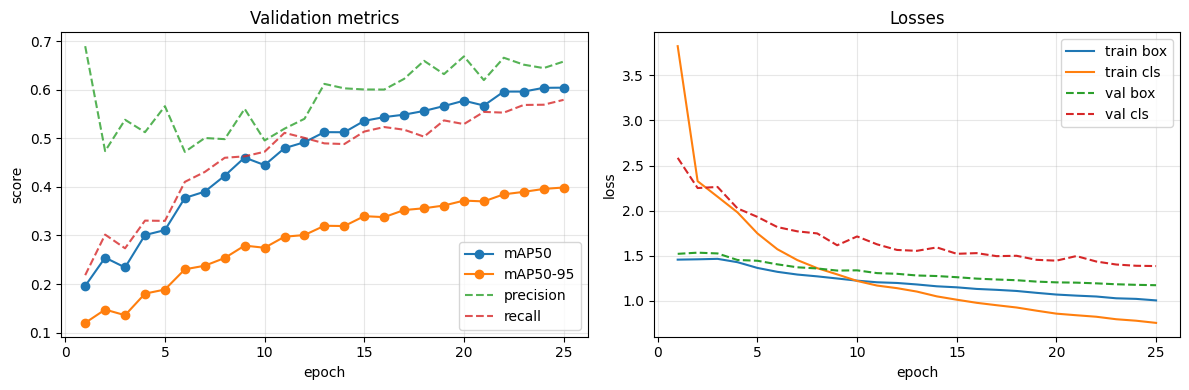

best epoch (by mAP50): 25
  mAP50:     0.605
  mAP50-95:  0.399
  precision: 0.658
  recall:    0.579
weights: F:\Final Project\Nutrivision\Code\Training model\runs\nutrivision_merged_final\weights\best.pt


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
RUN_DIR = NOTEBOOK_DIR / "runs" / "nutrivision_merged_final"
RESULTS_CSV = RUN_DIR / "results.csv"

if not RESULTS_CSV.is_file():
    raise FileNotFoundError(f"no results yet — run train.py first:\n  {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label="mAP50")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], marker="o", label="mAP50-95")
axes[0].plot(df["epoch"], df["metrics/precision(B)"], linestyle="--", alpha=0.8, label="precision")
axes[0].plot(df["epoch"], df["metrics/recall(B)"], linestyle="--", alpha=0.8, label="recall")
axes[0].set(xlabel="epoch", ylabel="score", title="Validation metrics")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/box_loss"], label="train box")
axes[1].plot(df["epoch"], df["train/cls_loss"], label="train cls")
axes[1].plot(df["epoch"], df["val/box_loss"], linestyle="--", label="val box")
axes[1].plot(df["epoch"], df["val/cls_loss"], linestyle="--", label="val cls")
axes[1].set(xlabel="epoch", ylabel="loss", title="Losses")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best = df.loc[df["metrics/mAP50(B)"].idxmax()]
print(f"best epoch (by mAP50): {int(best['epoch'])}")
print(f"  mAP50:     {best['metrics/mAP50(B)']:.3f}")
print(f"  mAP50-95:  {best['metrics/mAP50-95(B)']:.3f}")
print(f"  precision: {best['metrics/precision(B)']:.3f}")
print(f"  recall:    {best['metrics/recall(B)']:.3f}")
print(f"weights: {RUN_DIR / 'weights' / 'best.pt'}")